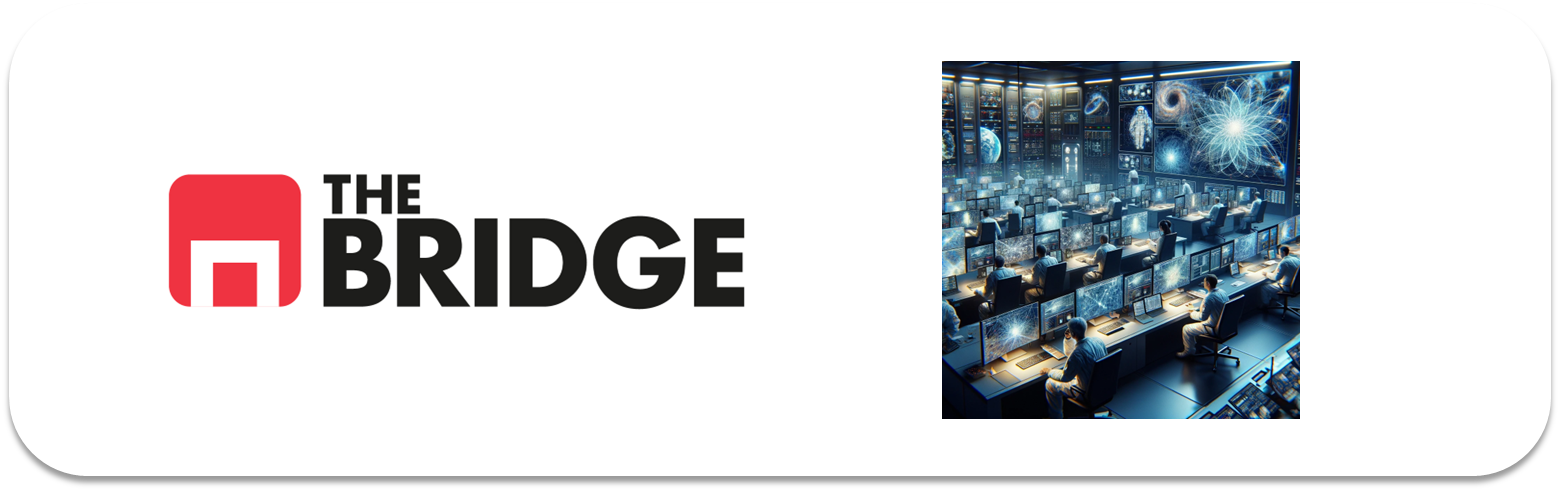

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

import os
import cv2

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks

tf.random.set_seed(42)

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



## Carga, comprobación y visualización de datos

In [2]:
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/seg_test/"

In [3]:
# --- Función de carga ---
def read_data(directorio, reshape_dim=(32, 32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):
                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim)  # Redimensionamos las imágenes a 32x32
                X.append(image)
                y.append(folder)
    return np.array(X), np.array(y)

# --- Carga de train y test ---
X_train, y_train = read_data(TRAIN_PATH, reshape_dim=(32, 32))
X_test, y_test = read_data(TEST_PATH, reshape_dim=(32, 32))

In [4]:
# --- Tamaño y forma de los datos ---
print("=== Forma de los datos ===")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nNúmero de imágenes en train:", X_train.shape[0])
print("Número de imágenes en test:", X_test.shape[0])
print("Dimensiones de cada imagen (alto, ancho, canales):", X_train.shape[1:])

=== Forma de los datos ===
X_train: (14034, 32, 32, 3)
y_train: (14034,)
X_test: (3000, 32, 32, 3)
y_test: (3000,)

Número de imágenes en train: 14034
Número de imágenes en test: 3000
Dimensiones de cada imagen (alto, ancho, canales): (32, 32, 3)


In [5]:
# --- Tipos de datos ---
print("\n=== Tipos de datos ===")
print("dtype de X_train:", X_train.dtype)
print("dtype de y_train:", y_train.dtype)


=== Tipos de datos ===
dtype de X_train: uint8
dtype de y_train: <U9


In [6]:
# --- Rango de valores de píxeles ---
print("\n=== Rango de valores de píxeles ===")
print("Min:", X_train.min(), "Max:", X_train.max())
print("Media:", X_train.mean(), "Desviación estándar:", X_train.std())


=== Rango de valores de píxeles ===
Min: 0 Max: 255
Media: 113.9272575289624 Desviación estándar: 68.93926454348038


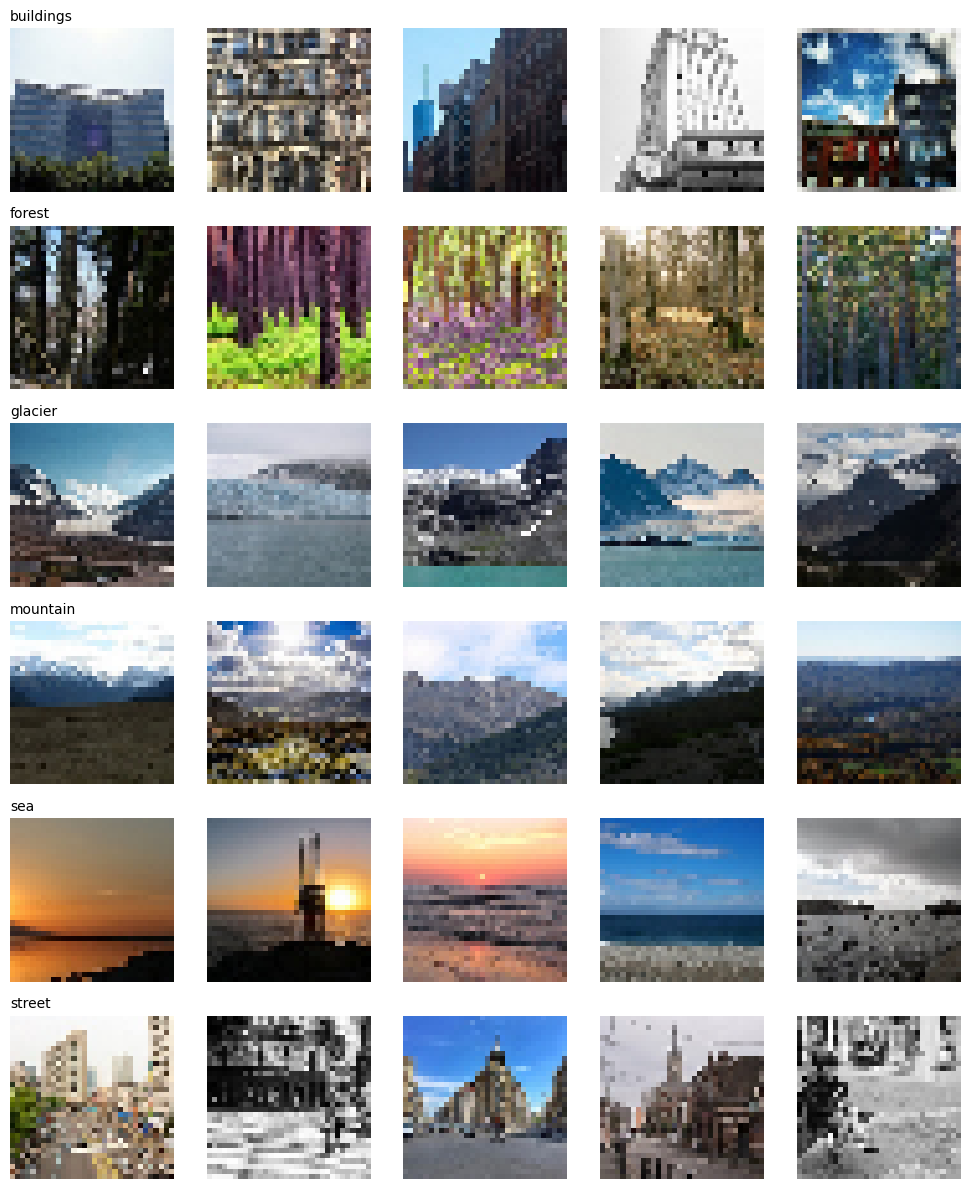


Formas únicas encontradas en X_train: {(32, 32, 3)}


In [7]:
# --- Comprobación visual: muestras aleatorias de cada clase ---
def plot_random_samples(X, y, n_por_clase=5, seed=42):
    rng = np.random.default_rng(seed)
    clases = np.unique(y)
    fig, axes = plt.subplots(len(clases), n_por_clase,
                              figsize=(n_por_clase * 2, len(clases) * 2))
    for i, clase in enumerate(clases):
        idx_clase = np.where(y == clase)[0]
        idx_muestra = rng.choice(idx_clase, size=n_por_clase, replace=False)
        for j, idx in enumerate(idx_muestra):
            ax = axes[i, j]
            ax.imshow(X[idx])
            ax.axis("off")
            if j == 0:
                ax.set_title(clase, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_random_samples(X_train, y_train, n_por_clase=5)

# --- Comprobación de que no hay imágenes con formas distintas o corruptas ---
formas_unicas = set(img.shape for img in X_train)
print("\nFormas únicas encontradas en X_train:", formas_unicas)

## MiniEDA

In [8]:
# --- Resumen general ---
print("=== Resumen general ===")
print(f"Imágenes en train: {X_train.shape[0]}")
print(f"Imágenes en test:  {X_test.shape[0]}")
print(f"Dimensiones por imagen: {X_train.shape[1:]}")
print(f"Número de clases: {len(np.unique(y_train))}")
print(f"Clases: {sorted(np.unique(y_train))}")

=== Resumen general ===
Imágenes en train: 14034
Imágenes en test:  3000
Dimensiones por imagen: (32, 32, 3)
Número de clases: 6
Clases: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]


In [9]:
# --- Estadísticos de los píxeles (antes de normalizar) ---
print("\n=== Estadísticos de píxeles (train, sin normalizar) ===")
print(f"Min: {X_train.min()}  Max: {X_train.max()}")
print(f"Media: {X_train.mean():.2f}  Desv. estándar: {X_train.std():.2f}")


=== Estadísticos de píxeles (train, sin normalizar) ===
Min: 0  Max: 255
Media: 113.93  Desv. estándar: 68.94


In [10]:
# --- Estadísticos por canal (R, G, B) ---
print("\n=== Estadísticos por canal (train) ===")
for i, canal in enumerate(["R", "G", "B"]):
    print(f"  Canal {canal} -> media: {X_train[:, :, :, i].mean():.2f}, "
          f"std: {X_train[:, :, :, i].std():.2f}")


=== Estadísticos por canal (train) ===
  Canal R -> media: 109.60, std: 66.31
  Canal G -> media: 116.56, std: 65.93
  Canal B -> media: 115.63, std: 74.06


In [11]:
# --- Distribución de clases (train vs test) ---
clases_train, counts_train = np.unique(y_train, return_counts=True)
clases_test, counts_test = np.unique(y_test, return_counts=True)

df_dist = pd.DataFrame({
    "clase": clases_train,
    "train": counts_train,
    "train_%": (counts_train / len(y_train) * 100).round(2)
}).merge(
    pd.DataFrame({"clase": clases_test, "test": counts_test,
                  "test_%": (counts_test / len(y_test) * 100).round(2)}),
    on="clase"
)
print("\n=== Distribución de clases ===")
print(df_dist)


=== Distribución de clases ===
       clase  train  train_%  test  test_%
0  buildings   2191    15.61   437   14.57
1     forest   2271    16.18   474   15.80
2    glacier   2404    17.13   553   18.43
3   mountain   2512    17.90   525   17.50
4        sea   2274    16.20   510   17.00
5     street   2382    16.97   501   16.70


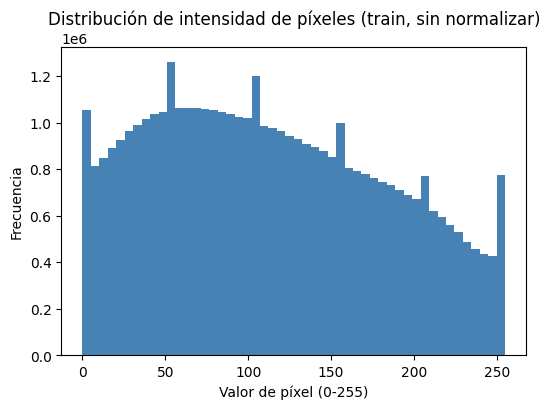

In [12]:
# --- Histograma de intensidad de píxeles ---
plt.figure(figsize=(6, 4))
plt.hist(X_train.ravel(), bins=50, color="steelblue")
plt.title("Distribución de intensidad de píxeles (train, sin normalizar)")
plt.xlabel("Valor de píxel (0-255)")
plt.ylabel("Frecuencia")
plt.show()

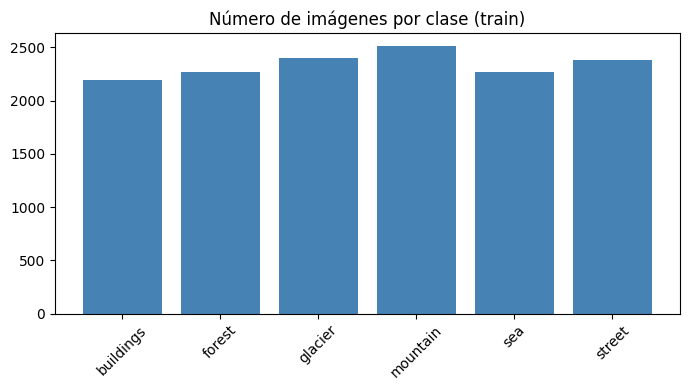

In [13]:
# --- Balance de clases (gráfico) ---
plt.figure(figsize=(7, 4))
plt.bar(df_dist["clase"], df_dist["train"], color="steelblue")
plt.title("Número de imágenes por clase (train)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Normalización de features y preprocesado 


=== Tras la normalización ===
dtype: float32
Min: 0.0  Max: 1.0
Media: 0.4468  Desv. estándar: 0.2703


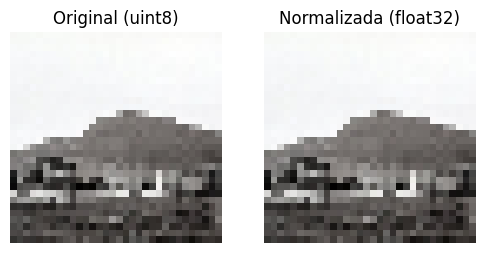

In [ ]:
# --- Normalización para la CNN ad-hoc
# Los píxeles están en uint8 (0-255). Escalamos a [0, 1] en float32
# (float32 en vez de float64 para ahorrar memoria, algo relevante con datasets de imágenes)
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print("\n=== Tras la normalización ===")
print(f"dtype: {X_train_norm.dtype}")
print(f"Min: {X_train_norm.min()}  Max: {X_train_norm.max()}")
print(f"Media: {X_train_norm.mean():.4f}  Desv. estándar: {X_train_norm.std():.4f}")

# --- Comprobación visual de que la normalización no altera las imágenes ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_train[0])
axes[0].set_title("Original (uint8)")
axes[0].axis("off")
axes[1].imshow(X_train_norm[0])
axes[1].set_title("Normalizada (float32)")
axes[1].axis("off")
plt.show()

In [ ]:
# ==================================================================
# --- Codificar etiquetas de TEXTO -> enteros (Keras no admite texto) --
#    Dos diccionarios: ida (texto->num) y vuelta (num->texto)
# ==================================================================
clases = sorted(np.unique(y_train))
label_to_num = {c: i for i, c in enumerate(clases)}
num_to_label = {i: c for c, i in label_to_num.items()}
N_CLASES = len(clases)

y_train_enc = np.array([label_to_num[l] for l in y_train])
y_test_enc  = np.array([label_to_num[l] for l in y_test])
print("Clases:", clases, "\nN_CLASES:", N_CLASES)

Clases: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')] 
N_CLASES: 6


In [ ]:
# ==================================================================
# --- Barajar el train (viene ORDENADO por carpeta -> imprescindible --
#    antes de validation_split, o la validación sería de una sola clase)
# ==================================================================
X_train_sh, y_train_sh = shuffle(X_train, y_train_enc, random_state=42)

In [19]:
# ==================================================================
# --- Preprocesado propio de MobileNetV2 (espera 0-255, escala a [-1,1]) ---
#    OJO: NO usar X_train_norm aquí. Ese [0,1] es para la CNN ad-hoc;
#    el modelo preentrenado necesita SU preprocess_input sobre el 0-255.
# ==================================================================
X_train_prep = preprocess_input(X_train_sh.astype("float32"))
X_test_prep  = preprocess_input(X_test.astype("float32"))

# Transfer learning

## Creación del modelo MobileNetV2

In [20]:
# ==================================================================
# 4. Modelo: MobileNetV2 SIN cabeza + base CONGELADA + cabeza propia
#    Cabeza: 2 densas ocultas + salida 
# ==================================================================
IMG_SIZE = X_train.shape[1:]   # (32, 32, 3)

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE,
    pooling="avg"              # salida plana (None, 1280)
)
base.trainable = False         # transfer learning: base congelada

model_tl = models.Sequential([
    base,
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(N_CLASES, activation="softmax"),
], name="transfer_learning")

model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_tl.summary()

C:\Users\user\AppData\Local\Temp\ipykernel_8600\889549894.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,590 (9.99 MB)

 Trainable params: 361,606 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Entrenamiento del modelo MobileNetV2

In [21]:
early = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_tl = model_tl.fit(
    X_train_prep, y_train_sh,
    validation_split=0.2,
    batch_size=64,
    epochs=100,
    callbacks=[early],
    verbose=1
)


Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.4283 - loss: 1.4177 - val_accuracy: 0.4717 - val_loss: 1.2602
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.4953 - loss: 1.2642 - val_accuracy: 0.5045 - val_loss: 1.2312
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.5096 - loss: 1.2289 - val_accuracy: 0.5109 - val_loss: 1.2238
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.5242 - loss: 1.1972 - val_accuracy: 0.5151 - val_loss: 1.2169
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.5321 - loss: 1.1763 - val_accuracy: 0.5159 - val_loss: 1.2138
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.5383 - loss: 1.1552 - val_accuracy: 0.5230 - val_loss: 1.2121
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.5473 - loss: 1.1369 - val_accuracy: 0.5183 - val_loss: 1.2172
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.5557 - loss: 1.1158 -

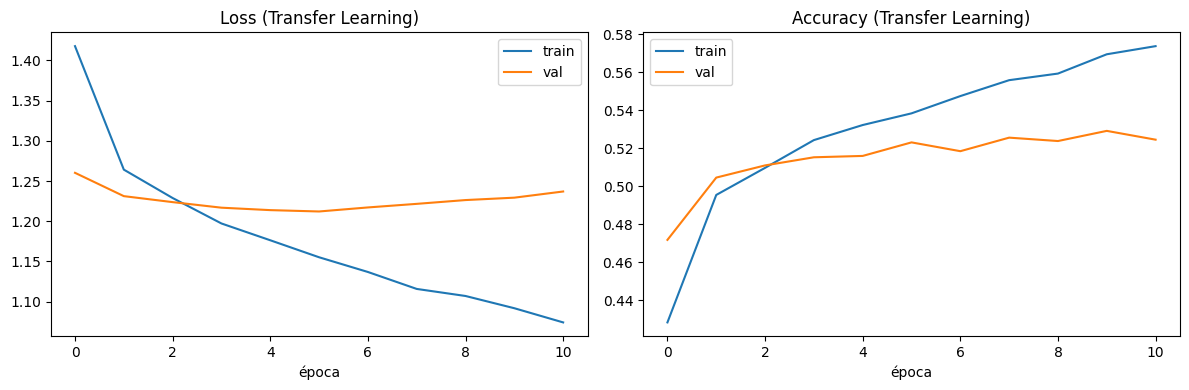

In [22]:
# ==================================================================
# Curvas de evolución
# ==================================================================
def plot_history(history, titulo=""):
    h = history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h["loss"], label="train"); plt.plot(h["val_loss"], label="val")
    plt.title(f"Loss {titulo}"); plt.xlabel("época"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h["accuracy"], label="train"); plt.plot(h["val_accuracy"], label="val")
    plt.title(f"Accuracy {titulo}"); plt.xlabel("época"); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(history_tl, "(Transfer Learning)")

## Evaluación en test del modelo MobileNetV2 + classification report + matriz de confusión


Test accuracy: 0.5030 | Test loss: 1.2350

              precision    recall  f1-score   support

   buildings      0.358     0.627     0.456       437
      forest      0.770     0.869     0.817       474
     glacier      0.509     0.353     0.417       553
    mountain      0.491     0.575     0.530       525
         sea      0.534     0.306     0.389       510
      street      0.415     0.339     0.373       501

    accuracy                          0.503      3000
   macro avg      0.513     0.512     0.497      3000
weighted avg      0.514     0.503     0.493      3000



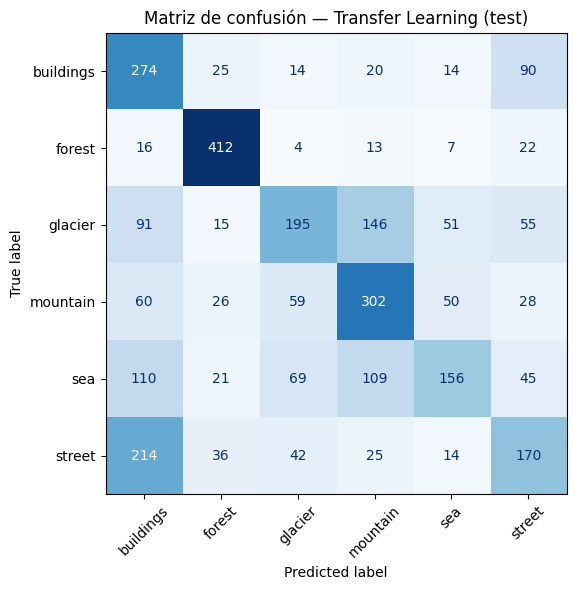

In [23]:
loss, acc = model_tl.evaluate(X_test_prep, y_test_enc, verbose=0)
print(f"\nTest accuracy: {acc:.4f} | Test loss: {loss:.4f}")

y_pred = np.argmax(model_tl.predict(X_test_prep, batch_size=64, verbose=0), axis=1)

print("\n" + classification_report(y_test_enc, y_pred, target_names=clases, digits=3))

cm = confusion_matrix(y_test_enc, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=clases).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — Transfer Learning (test)")
plt.tight_layout(); plt.show()

### Transfer Learning (MobileNetV2, base congelada) — análisis

**Resultado:** test accuracy 0.503 | F1 macro 0.497 (azar = 0.167)

**Curvas:** el train_accuracy sube (0.43→0.57) pero el val_accuracy se estanca en ~0.52 desde la época 5-6, y la val_loss empieza a subir ahí (EarlyStopping corta en la época 11). Hay sobreajuste incipiente, pero el train_accuracy tampoco es alto: el modelo ha tocado techo, no solo memoriza.

**Matriz de confusión — errores semánticamente coherentes:**
- forest: recall 0.869 (verde/textura inconfundible)
- street → buildings (214): las calles contienen edificios
- glacier ↔ mountain (146): masas gris-azuladas similares
- sea → glacier/mountain: superficies extensas sin textura distintiva
- buildings actúa de "sumidero" (recall 0.627 / precision 0.358)

**Conclusión:** el transfer learning con base congelada a 32×32 rinde pobremente porque las features de ImageNet no pueden explotarse a esta resolución. Esto motiva el fine-tuning (descongelar y readaptar la base) del punto siguiente.

# Fine-tuning

## Ajuste del modelo

In [ ]:
# Ver nombres de capas para ver a partir de cual descongelar

In [24]:
for i, layer in enumerate(base.layers):
    print(i, layer.name)

0 input_layer
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_relu


### Justificación del punto de descongelado (block_13)

MobileNetV2 aprende features jerárquicas: las primeras capas capturan
patrones genéricos (bordes, colores, texturas) transferibles a cualquier
imagen, y las últimas codifican conceptos abstractos específicos de las
clases de ImageNet. Por eso congelamos las primeras capas (features ya
óptimas y reutilizables) y descongelamos solo la parte final, que es la
que interesa readaptar a las clases de paisajes.

Elegimos `block_13` como punto de corte porque libera aproximadamente el
último tercio de la red (bloques 13-16 + Conv_1), un equilibrio estándar
entre capacidad de adaptación y riesgo de sobreajuste dado el volumen de
datos (~14k imágenes). El corte se hace al inicio de un bloque para no
partir la estructura de residuos de la arquitectura.

Este punto es un hiperparámetro: descongelar desde un bloque anterior
(block_11) daría más adaptación a costa de más sobreajuste, y desde uno
posterior (block_14) sería más conservador.

Capas entrenables en la base: 26 de 155
Parámetros entrenables totales: 2,024,966
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.5860 - loss: 1.0612 - val_accuracy: 0.5992 - val_loss: 1.0549
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.6342 - loss: 0.9516 - val_accuracy: 0.6316 - val_loss: 1.0106
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.6638 - loss: 0.8872 - val_accuracy: 0.6477 - val_loss: 0.9487
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.6806 - loss: 0.8266 - val_accuracy: 0.6626 - val_loss: 0.9241
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.6989 - loss: 0.7881 - val_accuracy: 0.6665 - val_loss: 0.8960
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.7204 - loss: 0.7433 - val_accuracy: 0.6701 - val_loss: 0.8945
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.7312 - loss: 0.7135 - val_accuracy: 0.6851 - val_loss: 0.8841
E

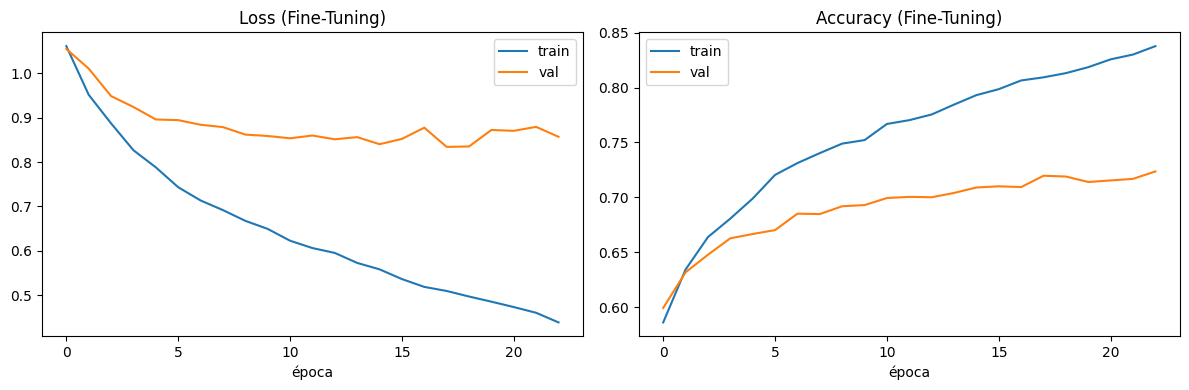


Test accuracy (fine-tuning): 0.7263 | Test loss: 0.8290

              precision    recall  f1-score   support

   buildings      0.706     0.719     0.712       437
      forest      0.924     0.895     0.909       474
     glacier      0.665     0.687     0.676       553
    mountain      0.642     0.693     0.667       525
         sea      0.720     0.625     0.669       510
      street      0.734     0.754     0.744       501

    accuracy                          0.726      3000
   macro avg      0.732     0.729     0.730      3000
weighted avg      0.729     0.726     0.727      3000



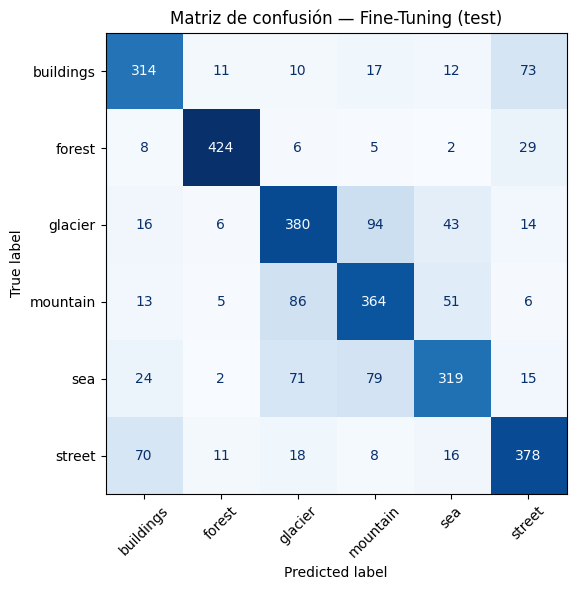

In [25]:
# ==================================================================
# 1. Descongelar la base DESDE el bloque 13 en adelante
# ==================================================================
base.trainable = True

set_trainable = False
for layer in base.layers:
    if layer.name.startswith("block_13"):   # a partir de este bloque -> entrenable
        set_trainable = True
    layer.trainable = set_trainable

# Las BatchNormalization SIEMPRE congeladas: reentrenar sus estadísticas
# con batches pequeños a 32x32 desestabiliza el entrenamiento.
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# ==================================================================
# 2. RECOMPILAR con learning rate MUY bajo (imprescindible)
#    Sin recompilar, el cambio de 'trainable' no surte efecto.
# ==================================================================
model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Verificación de que el descongelado hizo lo esperado
n_entrenables = sum(layer.trainable for layer in base.layers)
params_entren = np.sum([np.prod(w.shape) for w in model_tl.trainable_weights])
print(f"Capas entrenables en la base: {n_entrenables} de {len(base.layers)}")
print(f"Parámetros entrenables totales: {params_entren:,}")

# ==================================================================
# 3. Continuar el entrenamiento (fine-tuning)
# ==================================================================
early_ft = callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                   restore_best_weights=True)

history_ft = model_tl.fit(
    X_train_prep, y_train_sh,
    validation_split=0.2,
    batch_size=64,
    epochs=30,
    callbacks=[early_ft],
    verbose=1
)

# ==================================================================
# 4. Curvas
# ==================================================================
plot_history(history_ft, "(Fine-Tuning)")

# ==================================================================
# 5. Evaluación en test + report + matriz de confusión
# ==================================================================
loss_ft, acc_ft = model_tl.evaluate(X_test_prep, y_test_enc, verbose=0)
print(f"\nTest accuracy (fine-tuning): {acc_ft:.4f} | Test loss: {loss_ft:.4f}")

y_pred_ft = np.argmax(model_tl.predict(X_test_prep, batch_size=64, verbose=0), axis=1)
print("\n" + classification_report(y_test_enc, y_pred_ft, target_names=clases, digits=3))

cm_ft = confusion_matrix(y_test_enc, y_pred_ft)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_ft, display_labels=clases).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — Fine-Tuning (test)")
plt.tight_layout(); plt.show()

## Punto 6 — Comparación final de los tres enfoques

| Modelo | Test accuracy | F1 macro |
|---|---|---|
| Transfer Learning (base congelada) | 0.503 | 0.497 |
| Fine-Tuning (últimos bloques)      | 0.726 | 0.730 |
| CNN ad-hoc (desde cero)            | 0.809 | 0.81  |

**Resultado contraintuitivo: la CNN ad-hoc supera a los modelos preentrenados.**

**Explicación — el factor decisivo es la resolución (32×32):**
- La CNN ad-hoc está diseñada para 32×32: sus conv+pooling terminan en un
  mapa de 8×8 que conserva estructura espacial útil.
- MobileNetV2 está diseñada para 224×224 y reduce el tamaño espacial ×32,
  así que a 32×32 colapsa en un mapa de 1×1 antes de que sus features
  preentrenadas puedan actuar.

La ventaja de las features de ImageNet solo se materializa a alta
resolución. A 32×32 esa ventaja se pierde, y una red pequeña bien
dimensionada al tamaño real de los datos gana.

**Jerarquía de aprendizaje observada:**
- Transfer learning congelado (0.503): features de ImageNet inservibles a
  32×32, sin posibilidad de readaptarse.
- Fine-tuning (0.726): al descongelar, las features se readaptan (+22 pts),
  pero el cuello de botella de resolución persiste.
- CNN ad-hoc (0.809): arquitectura ajustada a 32×32, sin desventaja
  estructural.

**Conclusión:** el transfer learning NO es universalmente superior. Su
ventaja depende de que las condiciones (sobre todo la resolución de
entrada) se acerquen a las de su preentrenamiento. Con imágenes muy
pequeñas, una CNN ad-hoc adecuada al problema es preferible.

**Errores comunes a los tres modelos:** el trío glacier/mountain/sea
concentra el error residual (masas naturales azul-gris-blancas,
ambiguas a 32×32). forest es la clase más fácil en todos.